# Heart Disease Prediction: Exploratory Data Analysis

## Objective
To explore a clinical dataset of 918 patients and understand which patient characteristics (age, chest pain type, cholesterol, ST slope, etc.) are associated with heart disease, and to prepare clean, model-ready data.

## Dataset
- **Source:** [Heart Failure Prediction Dataset (Kaggle)](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)
- **Size:** 918 rows, 12 columns (11 features + 1 target)
- **Target:** `HeartDisease` (1 = heart disease, 0 = normal)

## Workflow
1. Data inspection
2. Data cleaning
3. Univariate analysis
4. Bivariate analysis
5. Correlation analysis
6. Encoding for modeling

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

## 2. Load the Dataset

In [2]:
df = pd.read_csv(r'../data/heart.csv')

## 3. Data Inspection
Checking the structure, data types, summary statistics, missing values and duplicates before any analysis.

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.shape

(918, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


**Observations:**
- The dataset has 918 rows and 12 columns with **no null values** and **no duplicate rows**.
- 5 columns are categorical (`Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`) and 7 are numeric.
- `RestingBP` and `Cholesterol` have a minimum value of **0**, which is not physiologically possible. These are hidden missing values and need to be handled.
- `Oldpeak` has a minimum of **-2.6**. Negative ST depression values are unusual and are kept as-is here (see note in the cleaning section).

In [6]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


13 rows
1.4161220043572984 %


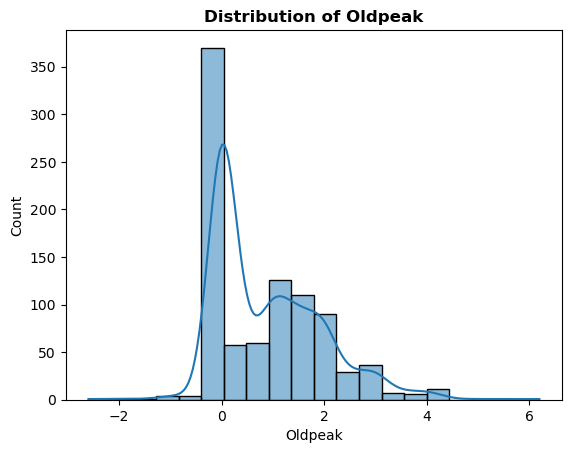

In [7]:
neg = df[df['Oldpeak'] < 0]
print(len(neg), "rows")
print(len(neg) / len(df) * 100, "%")

sns.histplot(df['Oldpeak'], kde=True, bins=20)
plt.title('Distribution of Oldpeak', fontweight='bold')
plt.show()

**Note on Oldpeak:** The minimum value is -2.6. Negative values represent ST elevation (instead of ST depression), which is clinically possible. So these 13 rows (1.4% of the data) were kept as valid observations.

In [8]:
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [9]:
df.duplicated().sum()

0

## 4. Target Variable Distribution

**Observation:** The target is fairly balanced: 508 patients (55%) have heart disease and 410 patients (45%) do not. No resampling (like SMOTE) is needed, and accuracy is a reasonable starting metric.

HeartDisease
1    508
0    410
Name: count, dtype: int64


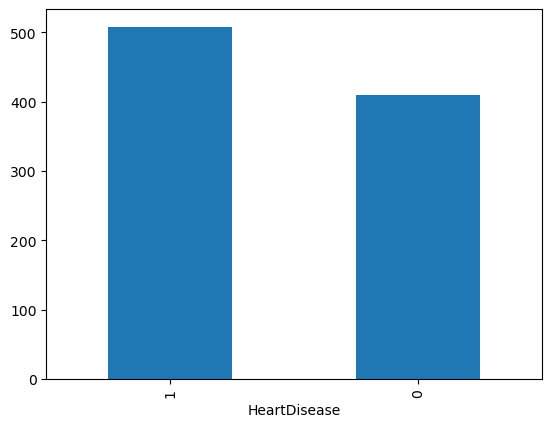

In [10]:
df['HeartDisease'].value_counts().plot(kind='bar')
print(df['HeartDisease'].value_counts())

## 5. Univariate Analysis: Numeric Features
Histograms with KDE to check the distribution and spot anomalies in `Age`, `RestingBP`, `Cholesterol` and `MaxHR`.

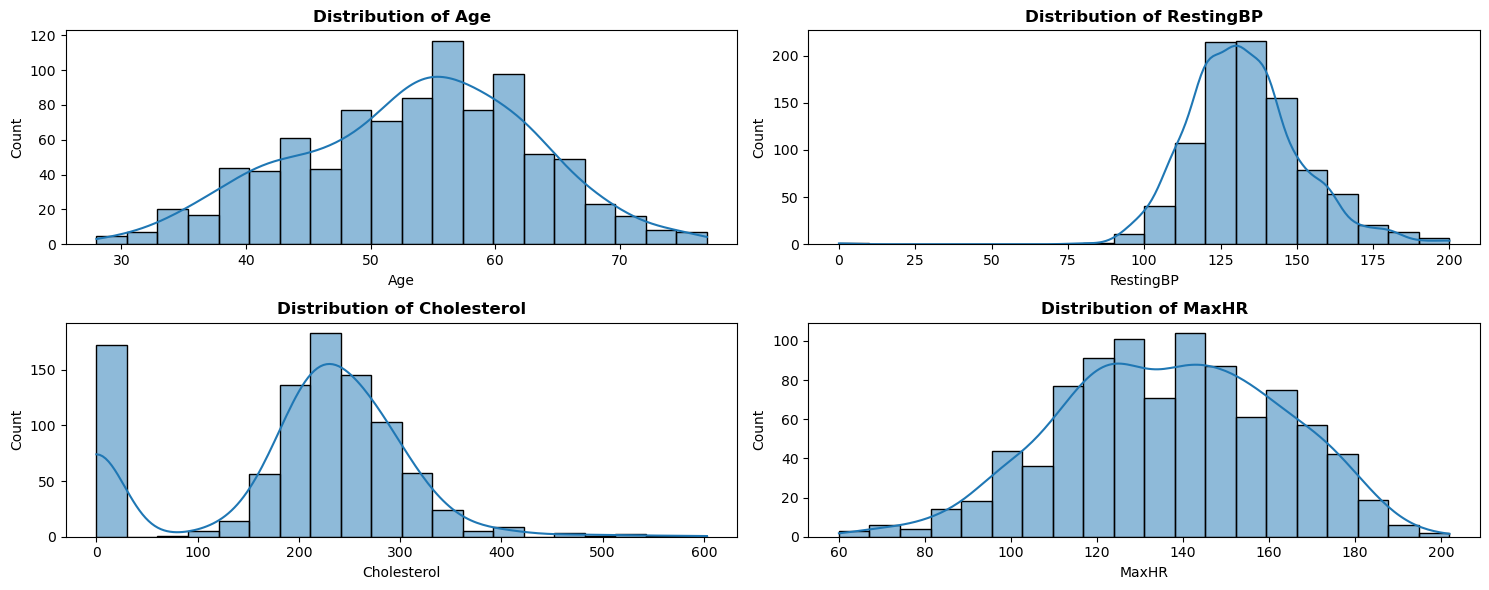

In [11]:
cols = ['Age','RestingBP','Cholesterol','MaxHR']
figure, axes = plt.subplots(2,2,figsize=(15,6))
for ax , col in zip(axes.flatten(),cols):
    sns.histplot(df[col],kde=True,ax=ax,bins=20)
    ax.set_title(f'Distribution of {col}',fontweight='bold')

plt.tight_layout()
plt.show()

**Observations:**
- `Age` is roughly normally distributed, with most patients between 45 and 65 years.
- `MaxHR` is also approximately normal.
- `Cholesterol` shows a large spike at **0**, and `RestingBP` has a zero value too. A human's resting blood pressure and cholesterol cannot be zero, so these are **missing values recorded as 0** and are treated in the next step.

## 6. Data Cleaning: Handling Invalid Zero Values

- `Cholesterol`: 172 rows (~19% of the data) have a value of 0.
- `RestingBP`: 1 row has a value of 0.

Both were replaced with the **mean of the non-zero values** of the respective column.

> **Limitation:** Mean imputation reduces the natural variance of `Cholesterol` (it creates a spike at the mean value). With ~19% of the values imputed, any conclusion about cholesterol should be treated with caution. For modeling, a median-based or model-based imputation (done after the train/test split to avoid data leakage) would be a better approach.

In [12]:
ch_mean = df.loc[df['Cholesterol'] != 0,'Cholesterol'].mean()
df['Cholesterol'] = df['Cholesterol'].replace(0,round(ch_mean,2))
df['Cholesterol'].value_counts()

Cholesterol
244.64    172
254.00     11
223.00     10
220.00     10
211.00      9
         ... 
353.00      1
278.00      1
157.00      1
176.00      1
131.00      1
Name: count, Length: 222, dtype: int64

In [13]:
resting_bp_mean = df.loc[df['RestingBP'] != 0,'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0,round(resting_bp_mean,2))
df['RestingBP'].value_counts()

RestingBP
120.0    132
130.0    118
140.0    107
110.0     58
150.0     55
        ... 
174.0      1
117.0      1
192.0      1
129.0      1
164.0      1
Name: count, Length: 67, dtype: int64

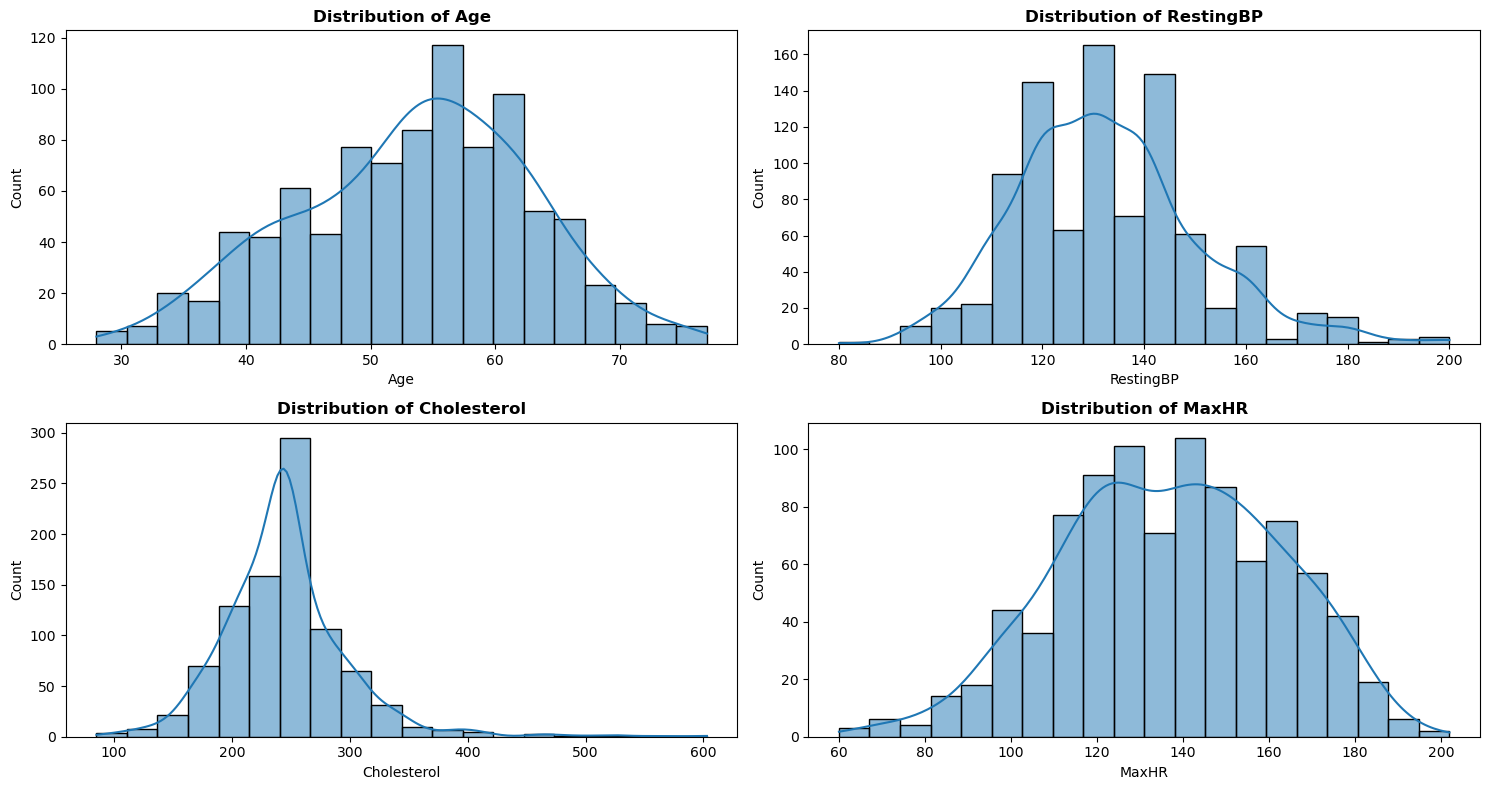

In [14]:
cols = ['Age','RestingBP','Cholesterol','MaxHR']
figure, axes = plt.subplots(2,2,figsize=(15,8))
for ax , col in zip(axes.flatten(),cols):
    sns.histplot(df[col],kde=True,ax=ax,bins=20)
    ax.set_title(f'Distribution of {col}',fontweight='bold')

plt.tight_layout()
plt.show()

**Observation:** After imputation the zero spikes are gone. `Cholesterol` now shows a sharp peak at the imputed mean value (~245), which is an expected side effect of mean imputation.

## 7. Bivariate Analysis: Categorical Features vs Heart Disease
Countplots of each categorical feature split by `HeartDisease`.

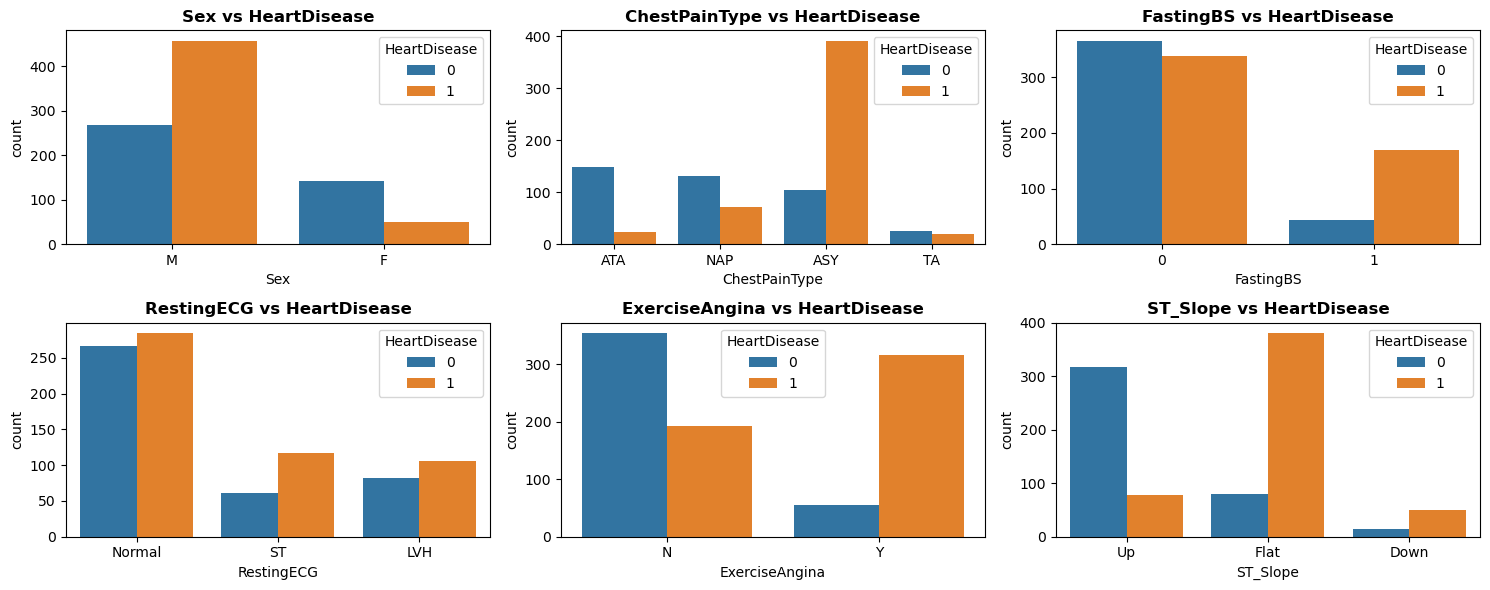

In [15]:
categorical_cols = ['Sex','ChestPainType','FastingBS','RestingECG','ExerciseAngina','ST_Slope']

fig, axes = plt.subplots(2, 3, figsize=(15, 6))

for ax, col in zip(axes.flatten(), categorical_cols):
    sns.countplot(data=df, x=col, hue='HeartDisease', ax=ax)
    ax.set_title(f'{col} vs HeartDisease', fontweight='bold')

plt.tight_layout()
plt.show()

**Observations:**
- **Sex:** Male patients have a noticeably higher proportion of heart disease than female patients.
- **ChestPainType:** `ASY` (asymptomatic) is the most common type among patients with heart disease, whereas `ATA` and `NAP` are mostly seen in patients without it.
- **ExerciseAngina:** Patients with exercise-induced angina (`Y`) are far more likely to have heart disease.
- **ST_Slope:** A `Flat` slope is strongly associated with heart disease, while an `Up` slope is mostly seen in healthy patients.
- **FastingBS:** Patients with fasting blood sugar > 120 mg/dl show a higher share of heart disease.
- **RestingECG:** Shows a weaker separation between the two classes compared to the other features.

## 8. Bivariate Analysis: Numeric Features vs Heart Disease
Boxplots to compare the distribution of numeric features for patients with and without heart disease.

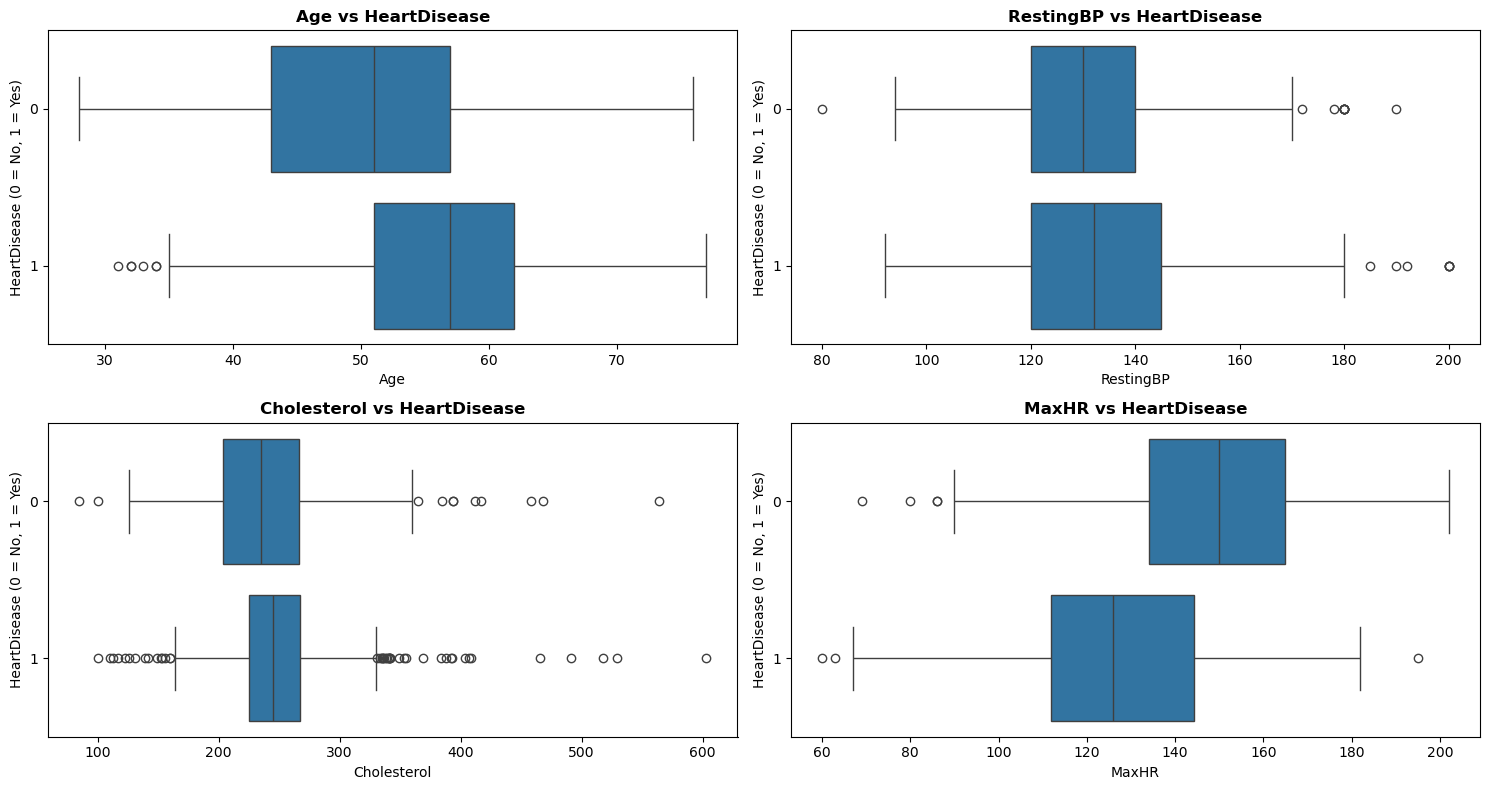

In [16]:
cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

for ax, col in zip(axes.flatten(), cols):
    sns.boxplot(data=df, x=col, y=df['HeartDisease'].astype(str), orient='h', ax=ax)
    ax.set_title(f'{col} vs HeartDisease', fontweight='bold')
    ax.set_ylabel('HeartDisease (0 = No, 1 = Yes)')

plt.tight_layout()
plt.show()

**Observations:**
- Patients with heart disease tend to be **older** (higher median `Age`).
- Patients with heart disease have a **lower `MaxHR`**, meaning a lower maximum heart rate achieved during exercise.
- `RestingBP` and `Cholesterol` show only a small difference between the two groups, and both contain several **outliers** (for example, a very high cholesterol value of 603). These outliers are retained because they are clinically possible values.

In [17]:
cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

for col in cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n} outliers ({n/len(df)*100:.1f}%), normal range = [{lower:.1f}, {upper:.1f}]")

Age: 0 outliers (0.0%), normal range = [27.5, 79.5]
RestingBP: 27 outliers (2.9%), normal range = [90.0, 170.0]
Cholesterol: 41 outliers (4.5%), normal range = [134.5, 346.5]
MaxHR: 2 outliers (0.2%), normal range = [66.0, 210.0]
Oldpeak: 16 outliers (1.7%), normal range = [-2.2, 3.8]


### 8.1 Outlier Analysis

Outliers were detected using the IQR method (values beyond 1.5 × IQR from Q1/Q3).

| Feature | Outliers | % of data | Normal range |
|---|---|---|---|
| Age | 0 | 0.0% | 27.5 to 79.5 |
| RestingBP | 27 | 2.9% | 90.0 to 170.0 |
| Cholesterol | 41 | 4.5% | 134.5 to 346.5 |
| MaxHR | 2 | 0.2% | 66.0 to 210.0 |
| Oldpeak | 16 | 1.7% | -2.2 to 3.8 |

**Observations:**
- `Age` has no outliers, and `MaxHR` has only 2.
- `Cholesterol` has the most outliers (4.5%), followed by `RestingBP` (2.9%) and `Oldpeak` (1.7%).
- Overall, the share of outliers per feature is small (under 5%).

**Decision:** The outliers were **retained**. Values such as a cholesterol of 603 mg/dl or a resting BP of 200 mm Hg are extreme but clinically possible, and removing them would discard real patient cases from an already small dataset (918 rows).

For modeling, tree-based models (Random Forest, XGBoost) are robust to outliers. If Logistic Regression is used, outliers can be capped (winsorized) or the features scaled.

## 9. Correlation Analysis

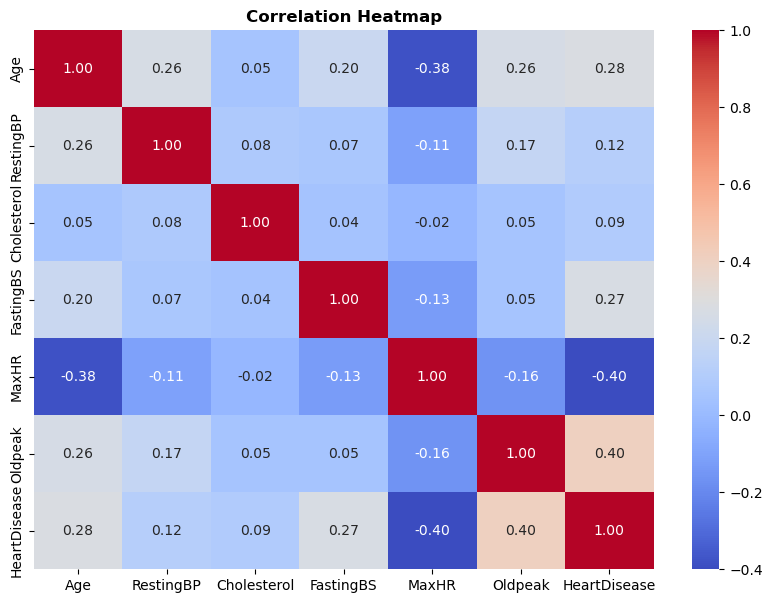

In [18]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap', fontweight='bold')
plt.show()

**Observations:**
- `Oldpeak` has the strongest positive correlation with `HeartDisease`, followed by `Age` and `FastingBS`.
- `MaxHR` has a **negative** correlation with `HeartDisease` (lower max heart rate, higher risk).
- No pair of numeric features is highly correlated with each other, so multicollinearity among numeric features is not a concern.

## 10. Data Preprocessing: Encoding Categorical Variables

Machine learning models need numeric input, so the categorical columns are converted using **one-hot encoding** (`pd.get_dummies`).

- `drop_first=False` keeps all category columns, which is suitable for tree-based models.
- For linear models such as Logistic Regression, use `drop_first=True` to avoid the **dummy variable trap** (multicollinearity).
- `dtype=int` is used so the encoded columns are 0/1 instead of True/False.

In [19]:
df_encode = pd.get_dummies(df,drop_first=False,dtype=int)
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,49,160.0,180.0,0,156,1.0,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,37,130.0,283.0,0,98,0.0,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,48,138.0,214.0,0,108,1.5,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,54,150.0,195.0,0,122,0.0,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,0,1,0,...,0,1,0,1,0,1,0,0,1,0
914,68,144.0,193.0,1,141,3.4,1,0,1,1,...,0,0,0,1,0,1,0,0,1,0
915,57,130.0,131.0,0,115,1.2,1,0,1,1,...,0,0,0,1,0,0,1,0,1,0
916,57,130.0,236.0,0,174,0.0,1,1,0,0,...,0,0,1,0,0,1,0,0,1,0


## 11. Key Findings

1. The dataset is clean (no nulls or duplicates) but contained hidden missing values: 172 zeros in `Cholesterol` and 1 in `RestingBP`.
2. The target classes are fairly balanced (55% vs 45%).
3. The strongest indicators of heart disease are **ST_Slope (Flat)**, **ExerciseAngina (Yes)**, **ChestPainType (ASY)**, higher **Oldpeak** and lower **MaxHR**.
4. Male patients and older patients show a higher prevalence of heart disease.
5. `Cholesterol` and `RestingBP` show only a weak relationship with the target in this dataset.

## 12. Next Steps
- Train and compare Logistic Regression, Random Forest and XGBoost.
- Evaluate using precision, recall, F1-score and ROC-AUC (recall is especially important in a medical setting).
- Analyze feature importance.
- Improve imputation (median / model-based) after the train/test split.